In [4]:
import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image

# --- 1. Konfiguration ---
dataset_path = '../data/processed/dataset_idle/' # Dein Ordner mit den gesunden Bildern
batch_size = 16

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Normalisierung wie beim ResNet, damit die Pixelwerte vergleichbar bleiben
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- 2. Dataset & Loader erstellen ---
# ImageFolder erwartet Unterordner, falls deine Bilder direkt in dataset_idle liegen,
# nutzen wir ein einfaches Custom Dataset oder schieben sie kurz in einen Unterordner 'healthy'
if any(os.path.isdir(os.path.join(dataset_path, d)) for d in os.listdir(dataset_path)):
    full_dataset = datasets.ImageFolder(root=dataset_path, transform=data_transforms)
else:
    # Falls keine Unterordner da sind, nehmen wir eine einfache Liste
    class SimpleDataset(torch.utils.data.Dataset):
        def __init__(self, root, transform):
            self.root = root
            self.transform = transform
            self.files = [f for f in os.listdir(root) if f.endswith(('.png', '.jpg'))]
        def __len__(self): return len(self.files)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.root, self.files[i])).convert('RGB')
            return self.transform(img), 0 # Dummy Label

    full_dataset = SimpleDataset(dataset_path, data_transforms)

train_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset geladen: {len(full_dataset)} gesunde Bilder gefunden.")

Dataset geladen: 283 gesunde Bilder gefunden.


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Die Autoencoder Architektur ---
class MotorAutoencoder(nn.Module):
    def __init__(self):
        super(MotorAutoencoder, self).__init__()
        
        # Encoder: Mehr Filter (32->64->128->256->512) für mehr Details
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),  # 112x112
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 56x56
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), # 28x28
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 3, stride=2, padding=1), # 14x14
            nn.LeakyReLU(0.2)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 3, 3, stride=2, padding=1, output_padding=1)
            # Sigmoid entfernt, damit er die normalisierten Werte (ResNet-Range) packt
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# --- 2. Modell & Training vorbereiten ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = MotorAutoencoder().to(device)

# WICHTIG: Wir trainieren NUR auf gesunden Daten (train_dataset)
# Der Loss ist hier der Mean Squared Error (MSE) zwischen Original und Rekonstruktion
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

# --- 3. Training Loop ---
print("Starte Training des Autoencoders auf gesunden Motoren...")
for epoch in range(30):
    autoencoder.train()
    train_loss = 0.0
    for inputs, _ in train_loader:
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = autoencoder(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    print(f"Epoche {epoch+1:02d} | MSE Loss: {train_loss/len(train_loader):.6f}")

# --- 4. Anomalie-Check Funktion ---
def check_anomaly(img_path, model, transform):
    model.eval()
    img_pil = Image.open(img_path).convert('RGB')
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        reconstruction = model(input_tensor)
        
        # Anomalie Score = MSE zwischen Original und Rekonstruktion
        loss = criterion(reconstruction, input_tensor)
        score = loss.item()
    
    # Visualisierung
    orig = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    recon = reconstruction.squeeze().cpu().numpy().transpose(1, 2, 0)
    diff = np.abs(orig - recon).mean(axis=2) # Differenz-Map
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(orig); plt.title("Original (Normal)")
    plt.subplot(1, 3, 2); plt.imshow(recon); plt.title("Rekonstruktion")
    plt.subplot(1, 3, 3); plt.imshow(diff, cmap='hot'); plt.title(f"Differenz (Score: {score:.6f})")
    plt.show()
    return score

Starte Training des Autoencoders auf gesunden Motoren...
Epoche 01 | MSE Loss: 0.707177
Epoche 02 | MSE Loss: 0.238499
Epoche 03 | MSE Loss: 0.135215
Epoche 04 | MSE Loss: 0.102514
Epoche 05 | MSE Loss: 0.089603
Epoche 06 | MSE Loss: 0.082225
Epoche 07 | MSE Loss: 0.078444
Epoche 08 | MSE Loss: 0.075699
Epoche 09 | MSE Loss: 0.071422
Epoche 10 | MSE Loss: 0.068618
Epoche 11 | MSE Loss: 0.071370
Epoche 12 | MSE Loss: 0.066153
Epoche 13 | MSE Loss: 0.062398
Epoche 14 | MSE Loss: 0.058508
Epoche 15 | MSE Loss: 0.055930
Epoche 16 | MSE Loss: 0.057210
Epoche 17 | MSE Loss: 0.060845
Epoche 18 | MSE Loss: 0.056486
Epoche 19 | MSE Loss: 0.052134
Epoche 20 | MSE Loss: 0.050005
Epoche 21 | MSE Loss: 0.048924
Epoche 22 | MSE Loss: 0.048052
Epoche 23 | MSE Loss: 0.047950
Epoche 24 | MSE Loss: 0.051223
Epoche 25 | MSE Loss: 0.084488
Epoche 26 | MSE Loss: 0.077675
Epoche 27 | MSE Loss: 0.057953
Epoche 28 | MSE Loss: 0.057045
Epoche 29 | MSE Loss: 0.046569
Epoche 30 | MSE Loss: 0.044368


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2317834].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2125204..2.7994084].


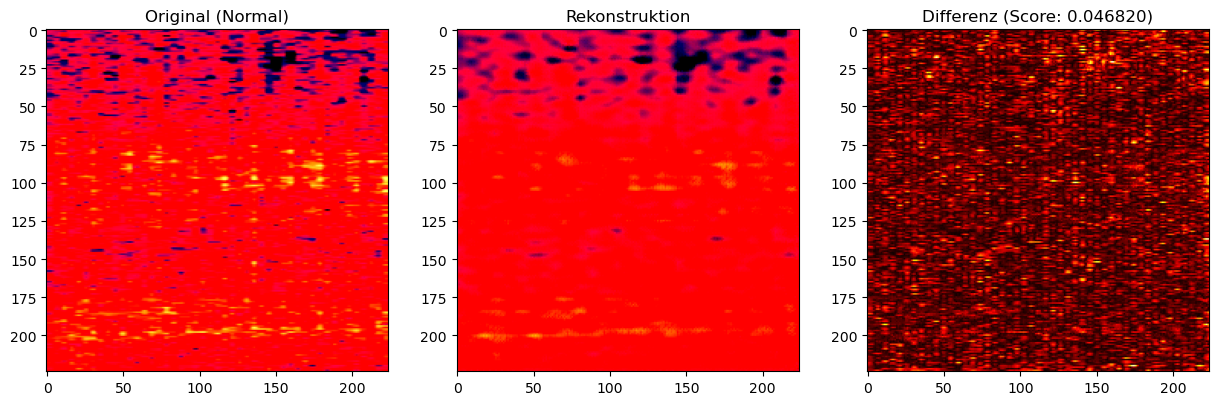

Anomalie-Score für dieses Bild: 0.046820


In [21]:
# Der Aufruf benötigt das Bild, das Modell UND die Vorverarbeitung (data_transforms)
score = check_anomaly(
    '../data/processed/dataset_idle_defective/S1000RR_2014_YoutubeVasylSuprovych_CamChainRattle_idle_10.50s.png', 
    autoencoder, 
    data_transforms
)

print(f"Anomalie-Score für dieses Bild: {score:.6f}")

In [25]:
def check_anomaly_boosted(img_path, model, transform):
    model.eval()
    img_pil = Image.open(img_path).convert('RGB')
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        reconstruction = model(input_tensor)
        
        # Berechne die absolute Differenz pro Pixel
        diff = torch.abs(input_tensor - reconstruction).squeeze().cpu().numpy()
        diff_map = diff.mean(axis=0) # Über die Kanäle mitteln
        
        # NEUER SCORE: Fokus auf die Top 10% der Fehler-Pixel
        # Ein Defekt ist lokal begrenzt und intensiv!
        threshold = np.percentile(diff_map, 95) 
        anomaly_score = diff_map[diff_map > threshold].mean()
        
    return anomaly_score, diff_map

# Teste das mal mit dem Defekt-Bild
score_boosted, diff_map = check_anomaly_boosted(
    '../data/processed/dataset_idle/S1000R_2015_PhilipKehl_cold_idle_13.50s.png', 
    autoencoder, 
    data_transforms
)
print(f"Boosted Anomalie-Score: {score_boosted:.6f}")

Boosted Anomalie-Score: 0.481629
